In [139]:
import numpy as np
from monodromy.render import _plot_coverage_set
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm
from weylchamber import c1c2c3

from gulps.gulps_synthesis import GulpsDecomposer
from gulps.synthesis_pass import GulpsDecompositionPass
from gulps.utils.invariants import GateInvariants
from gulps.utils.visualize import render_path

# from gulps.synthesis_plugin import GulpsSynthesisPlugin

### Usage as a Decomposer

In [140]:
gate_set = [
    # # CXGate(),
    # CXGate().power(1 / 2),
    iSwapGate().power(1 / 2),
    # iSwapGate().power(1 / 3),
]

costs = [1.0]  # , 1 / 2, 1 / 2, 1 / 3]
decomposer = GulpsDecomposer(gate_set, costs, precompute_polytopes=1)

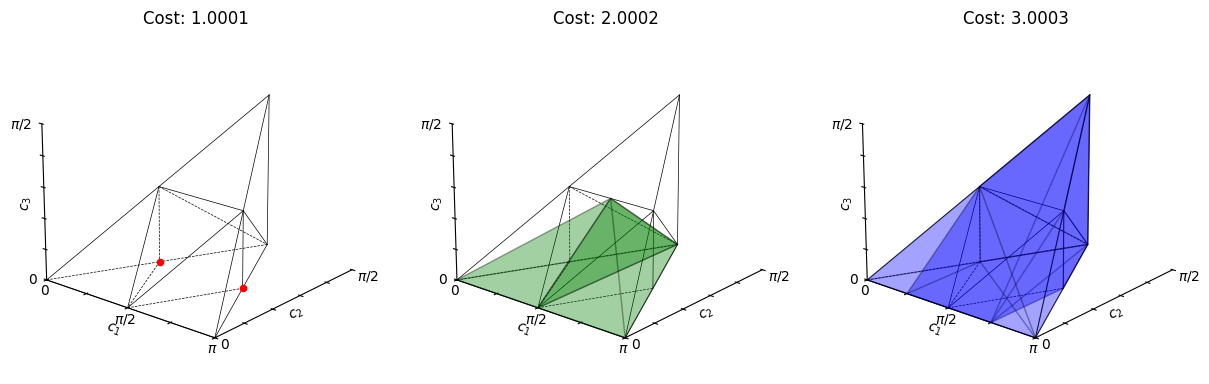

In [141]:
_plot_coverage_set(decomposer.isa.coverage_set)

In [146]:
N = 1_000
fidelities = []

for idx in tqdm(range(N)):
    u = random_unitary(4, seed=idx)
    v = Operator(decomposer(u))
    fid = average_gate_fidelity(u, v)
    fidelities.append(fid)

    if fid < 1 - 1e-6:
        print(f"Unitary {idx} fidelity is low: {fid:.8f}")
        print("Canonical invariants:")
        print("U:", c1c2c3(u))
        print("V:", c1c2c3(v))
        print("\n")
        continue

# Summary statistics
fidelities = np.array(fidelities)
print(f"\nSummary across {len(fidelities)} samples:")
print(f"  Median fidelity: {np.median(fidelities):.8f}")
print(f"  Mean fidelity:   {np.mean(fidelities):.8f}")
print(f"  Minimum fidelity:{np.min(fidelities):.8f}")

  0%|          | 0/1000 [00:00<?, ?it/s]

 60%|█████▉    | 596/1000 [00:17<00:14, 28.32it/s]

Unitary 593 fidelity is low: 0.99402474
Canonical invariants:
U: (np.float64(0.49965108), np.float64(0.31563953), np.float64(0.02754385))
V: (np.float64(0.5), np.float64(0.31563929), np.float64(0.0275429))




 71%|███████   | 707/1000 [00:20<00:07, 40.41it/s][gulps.utils.invariants] WARNING: Gates are not locally equivalent. Difference: [0.00057606 0.00016603 0.11726348]


Unitary 707 fidelity is low: 0.98904947
Canonical invariants:
U: (np.float64(0.49963327), np.float64(0.0510404), np.float64(0.0373988))
V: (np.float64(0.5), np.float64(0.0511461), np.float64(0.03725346))




 99%|█████████▊| 987/1000 [00:29<00:00, 28.56it/s]

Unitary 984 fidelity is low: 0.99998604
Canonical invariants:
U: (np.float64(0.6067575), np.float64(0.38285422), np.float64(0.01409131))
V: (np.float64(0.60479634), np.float64(0.38105786), np.float64(0.01408981))




100%|██████████| 1000/1000 [00:29<00:00, 33.65it/s]


Summary across 1000 samples:
  Median fidelity: 1.00000000
  Mean fidelity:   0.99998306
  Minimum fidelity:0.98904947


#### Inspecting the pieces

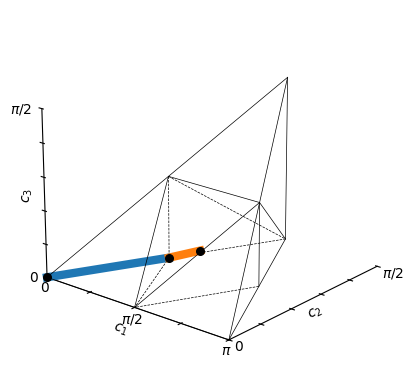

In [112]:
example_input = random_unitary(4, seed=None)
example_sentence, example_intermediates = decomposer._best_decomposition(
    target_inv=GateInvariants.from_unitary(example_input, enforce_alcove=True)
)
render_path(example_intermediates);

In [113]:
# NOTE, try with/out this reflection.
# the Decomposer has interal logic to handle this.
# example_intermediates = [x.rho_reflect for x in example_intermediates]

example_segment_solutions = decomposer._numerics._synthesize_segments(
    example_sentence, example_intermediates[1:]
)
print("Segment solutions:", example_segment_solutions)

Segment solutions: [array([-0.90601519, -6.33387578,  1.05235665,  1.8323297 ,  1.38945718,
        4.45988207])]


In [115]:
# Recover unitary equivalence by promoting local equivalence
ret = decomposer._numerics._stitch_segments(
    example_sentence, example_intermediates[1:], example_segment_solutions
)
U, V = c1c2c3(example_input), c1c2c3(Operator(ret).data)
print("Input unitary weyl invariants:", U)
print("Output unitary weyl invariants:", V)
ret.draw()

Input unitary weyl invariants: (np.float64(0.33285775), np.float64(0.30522004), np.float64(0.0136218))
Output unitary weyl invariants: (np.float64(0.33285775), np.float64(0.30522004), np.float64(0.0136218))


┌─────────┐┌──────────────────┐  ┌──────────────────────────┐ »
q_0: ┤ Unitary ├┤0                 ├──┤ Rv(1.8323,1.3895,4.4599) ├─»
     ├─────────┤│  (XX+YY)(-π/2,0) │┌─┴──────────────────────────┴┐»
q_1: ┤ Unitary ├┤1                 ├┤ Rv(-0.90602,-6.3339,1.0524) ├»
     └─────────┘└──────────────────┘└─────────────────────────────┘»
«     ┌──────────────────┐┌─────────┐
«q_0: ┤0                 ├┤ Unitary ├
«     │  (XX+YY)(-π/2,0) │├─────────┤
«q_1: ┤1                 ├┤ Unitary ├
«     └──────────────────┘└─────────┘

### Usage as a TransformationPass

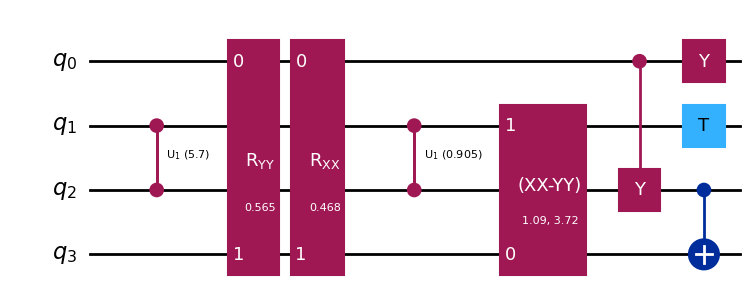

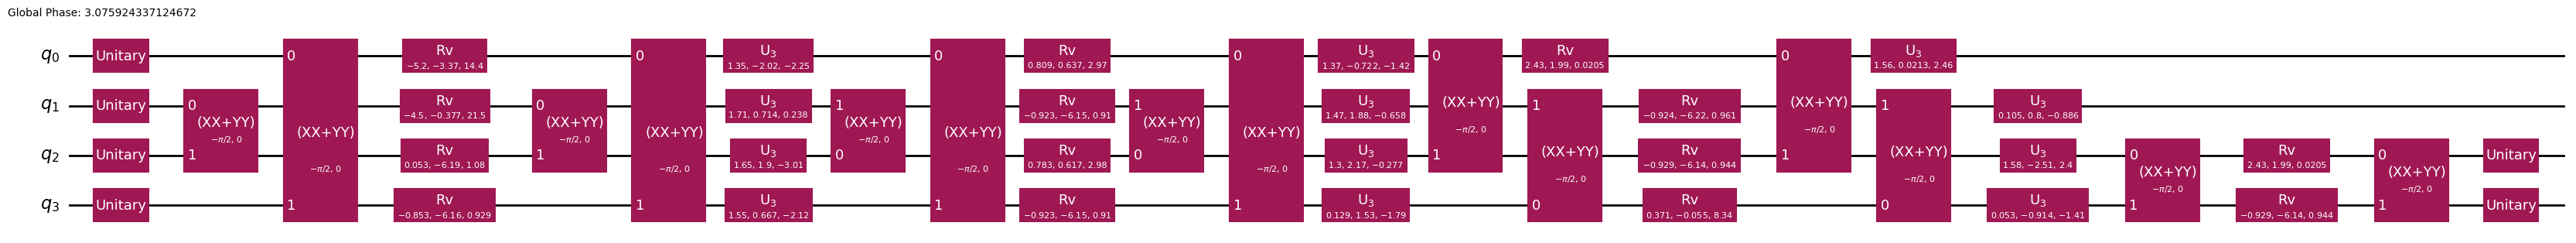

In [15]:
input_qc = random_circuit(
    4, 4, max_operands=2, num_operand_distribution={1: 0.2, 2: 0.8}
)
display(input_qc.draw("mpl"))

pm = PassManager(
    [
        GulpsDecompositionPass(gate_set, costs),
        Optimize1qGatesDecomposition(),
    ]
)
output_qc = pm.run(input_qc)
output_qc.draw("mpl", fold=-1)

### Usage as a Unitary Synthesis Plugin

In [16]:
# check that the plugin is installed
from qiskit.transpiler.passes.synthesis import unitary_synthesis_plugin_names

unitary_synthesis_plugin_names()

['gulps', 'aqc', 'clifford', 'default', 'sk']

In [17]:
# create some mock hetereogeneous ISA backend
target = Target()

target.add_instruction(
    RZXGate(np.pi / 2),
    {
        (0, 1): InstructionProperties(
            duration=100,
            error=0.01,
        )
    },
    name="cx",
)
target.add_instruction(
    RZXGate(np.pi / 4),
    {
        (0, 1): InstructionProperties(
            duration=50,
            error=0.05,
        )
    },
    name="scx",
)

target.add_instruction(
    XXPlusYYGate(np.pi),
    {
        (0, 1): InstructionProperties(
            duration=200,
            error=0.02,
        )
    },
    name="iswap",
)
target.add_instruction(
    XXPlusYYGate(np.pi / 2),
    {
        (0, 1): InstructionProperties(
            duration=100,
            error=0.01,
        )
    },
    name="siswap",
)

theta = Parameter("theta")
phi = Parameter("phi")
lam = Parameter("lambda")
u_props = {
    (0,): InstructionProperties(duration=0, error=0),
    (1,): InstructionProperties(duration=0, error=0),
}
target.add_instruction(UGate(theta, phi, lam), u_props)

In [18]:
circuit = QuantumCircuit(2)
# circuit.cx(0, 1)
circuit.append(UnitaryGate(Operator(CXGate())), [0, 1])

pass_manager = generate_preset_pass_manager(
    optimization_level=3,
    target=target,
    translation_method="synthesis",
    unitary_synthesis_method="gulps",
)

out = pass_manager.run(circuit)
out.draw("mpl")

TranspilerError: 'HighLevelSynthesis is unable to synthesize "cx"'